# EDA with the Enhanced Dataset

Checking a linear correlation between the newly calculated variables, `kpar`, `xmiss_summed`, `chl_a_summed`, and `phaeo_summed` with `secchi`. Note that these are all the values at the photic zone of the corresponding baselines. 

In [1]:
import sys
print(sys.executable)
import matplotlib
print(matplotlib.__file__)

/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/bin/python
/Users/aarti/Downloads/Scripps/Scripps-Light-Attenuation-Capstone-Project/.scripps/lib/python3.11/site-packages/matplotlib/__init__.py


In [2]:
# imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [3]:
# Loading the Dataset
CACHE_DIR = Path('../Data/Parquet')
CACHE_DIR.mkdir(exist_ok=True)

def load_or_cache(csv_path, parquet_path, usecols=None):
    parquet_path = Path(parquet_path)

    if parquet_path.exists():
        print(f"Loading cached: {parquet_path}")
        return pd.read_parquet(parquet_path)

    print(f"Reading CSV: {csv_path}")
    df = pd.read_csv(
        csv_path,
        usecols=usecols,
        low_memory=False
    )

    # Normalize object columns so Parquet doesn't choke
    obj_cols = df.select_dtypes(include="object").columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].astype("string")

    print(f"Caching → {parquet_path}")
    df.to_parquet(parquet_path)

    return df

enhanced_df = load_or_cache(
    '../Data/Enhanced.csv',
    CACHE_DIR / 'Enhanced.parquet'
)

Loading cached: ../Data/Parquet/Enhanced.parquet


In [17]:
# Checking if everything is numeric
for col in enhanced_df.columns:
    if enhanced_df[col].dtype != 'numeric':
        #print(f"Column '{col}' is of type '{enhanced_df[col].dtype}'.")
        enhanced_df[col] = pd.to_numeric(enhanced_df[col], errors='coerce')

#print(f"Column '{col}' is of type '{enhanced_df[col].dtype}'.")
# Checking for rows and columns, shape of the dataset
print(f"Dataset shape: {enhanced_df.shape}")

Dataset shape: (2388, 40)


Visualization saved to ../results/correlation_matrix_enhanced_dataset.png


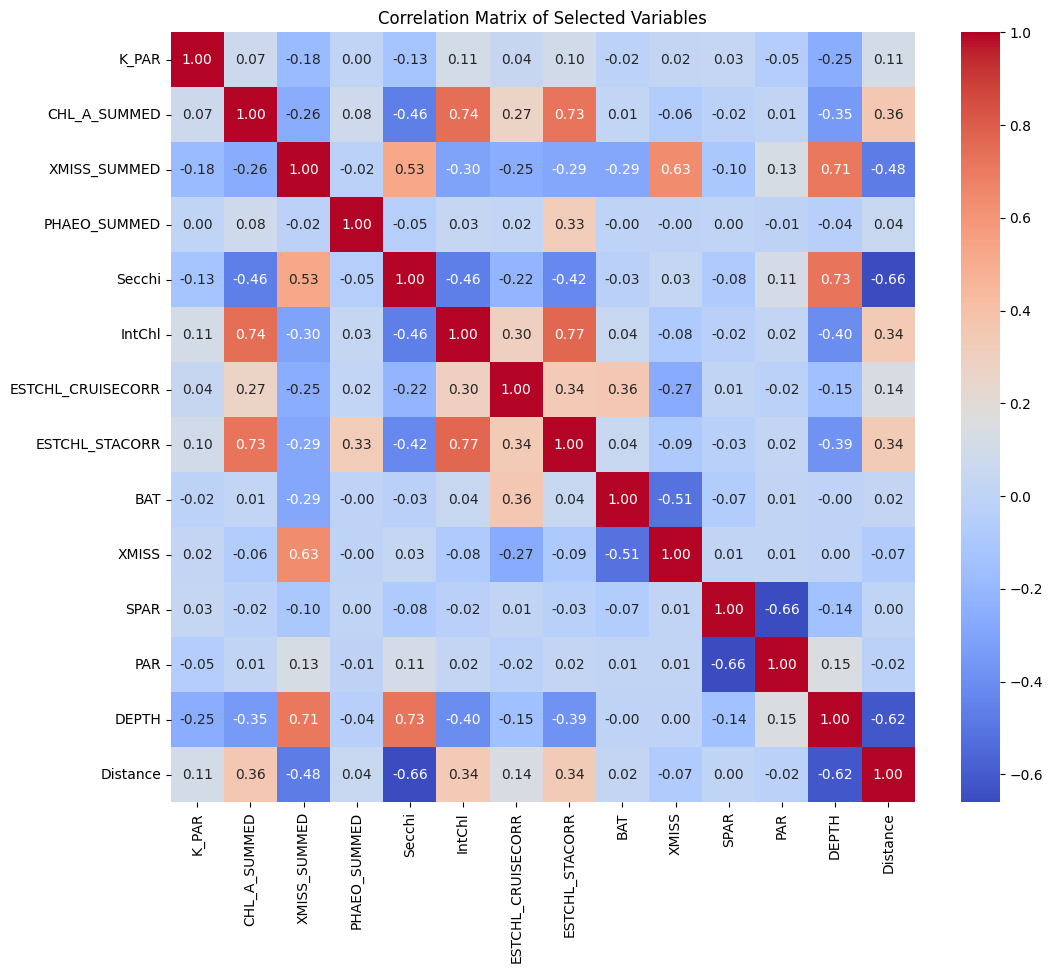

In [12]:
# Correlation analysis with variables kpar, chl_a_summed, xmiss_summed, phaeo_summed, secchi, depth, estchl_cruisecorr, 
# ESTCHL_STACORR	BAT	XMISS	SPAR	PAR
selected_columns = ['K_PAR', 'CHL_A_SUMMED', 'XMISS_SUMMED', 'PHAEO_SUMMED', 'Secchi', 
'IntChl', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'DEPTH', 'Distance']
correlation_matrix = enhanced_df[selected_columns].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Variables')

# Save correlation data
PLOT_PATH = Path("../results/correlation_matrix_enhanced_dataset.png")
plt.savefig(PLOT_PATH, dpi=300, bbox_inches='tight')
print(f"Visualization saved to {PLOT_PATH}")

plt.show()

# Running Random Forest on the enhanced data

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
import joblib

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.7s
[CV] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=

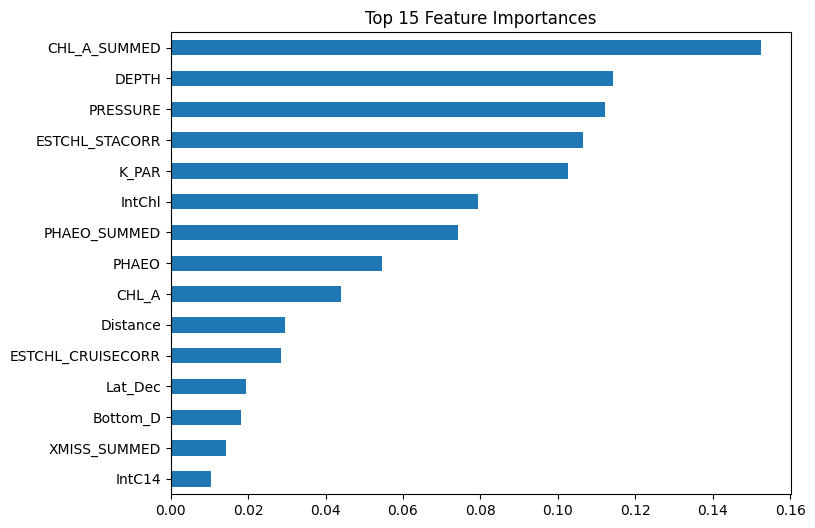

In [24]:
exclude_cols = ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA',
'CAST_COUNT','Cruise_ID','Cruz_Sta','Date','Time','TimeZone','PHOTIC_ZONE', 'Secchi']

# Feature columns for modeling, not in exclude_cols
feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols]

models_dir = Path("../Models")
models_dir.mkdir(exist_ok=True)

target_col = "Secchi"

feature_cols = [col for col in enhanced_df.columns if col not in exclude_cols + [target_col]]

X = enhanced_df[feature_cols].copy()
y = enhanced_df[target_col].copy()

# Drop rows with NA
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_features": ["sqrt", 0.3, 0.5],   # m_try
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",  # better than MSE
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

y_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²: {r2:.4f}")

model_path = models_dir / "enhanced_random_forest_model.pkl"
joblib.dump(best_rf, model_path)
print(f"Model saved to {model_path}")

importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

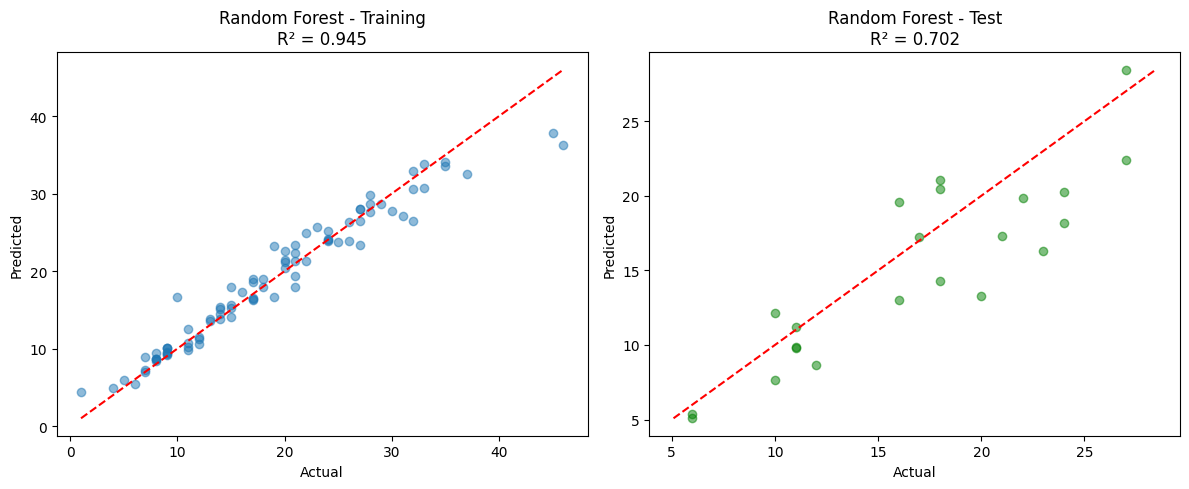

In [25]:
results = {}

# Training predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

results["random_forest"] = {
    "y_train": y_train,
    "y_train_pred": y_train_pred,
    "y_test": y_test,
    "y_test_pred": y_test_pred,
    "train_r2": r2_score(y_train, y_train_pred),
    "test_r2": r2_score(y_test, y_test_pred)
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.5)
min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[0].set_title(f"Random Forest - Training\nR² = {results['random_forest']['train_r2']:.3f}")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Test
axes[1].scatter(y_test, y_test_pred, alpha=0.5, color='green')
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--')
axes[1].set_title(f"Random Forest - Test\nR² = {results['random_forest']['test_r2']:.3f}")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()